# Big Data Content Analytics - AUEB

## Callbacks that reduce training time using Keras

* Lab Assistant: George Perakis
* Email: gperakis[at]aeub.gr 

### Imports

In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard

from tensorflow.keras.optimizers import SGD

# used to create mock-up data
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
### Create Mock-up dataset

In [3]:
n_feats = 20

X, y = make_classification(n_samples=100_000,
                           n_features=20,
                           n_informative=3,
                           n_redundant=0,
                           n_classes=2,
                           n_clusters_per_class=2)

pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.956980,0.453298,3.226750,0.162911,1.237619,2.314725,-0.467332,-0.992080,0.185105,0.037934,-0.552077,0.771385,0.546730,-0.085157,-2.118628,1.300660,-1.083795,2.275206,0.563865,-0.288895
1,0.475568,-1.865067,2.406993,-0.387032,1.179612,-1.152686,-0.238320,-1.250006,0.277407,0.625907,-0.023812,-0.040150,0.272559,0.720291,-0.181105,0.332676,-0.744335,2.170947,-0.060312,-1.068877
2,1.843545,0.763758,-0.141131,-0.282982,-0.262456,0.633988,-0.719033,0.072140,1.154155,0.713193,-0.359704,0.047865,0.352409,0.563853,0.885259,-1.558730,1.126733,-0.410466,-0.550984,-0.895042
3,0.606966,-0.902469,-1.279554,-0.773864,-0.729234,0.089260,0.125587,-0.259155,-2.355621,-1.305204,-1.063821,-1.258000,0.028617,1.102635,-0.126686,2.122066,-1.264883,-1.562780,1.857191,-0.752920
4,-0.700014,-0.381719,-1.393568,-0.741292,-0.988412,-0.994921,0.677991,0.023044,1.813030,0.987058,-1.407125,0.253108,1.210710,0.684538,0.248495,-1.169633,-0.240728,-0.724727,-0.050673,-0.819753


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [5]:
X_train.shape

(75000, 20)

In [6]:
X_train.shape[1]

20

### Build Sequential Model

In [7]:
# instantiate model
model = Sequential()

# we can think of this chunk as the input layer
model.add(Dense(128, input_dim=X_train.shape[1]))

model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

# we can think of this chunk as the hidden layer    
model.add(Dense(64))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# we can think of this chunk as the output layer
model.add(Dense(1))
model.add(BatchNormalization())
model.add(Activation('sigmoid'))

# setting up the optimization of our weights 
sgd = SGD(lr=0.1,
          decay=1e-6,
          momentum=0.9,
          nesterov=True)

model.compile(loss='binary_crossentropy',
              optimizer=sgd,
              metrics=['acc'])

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               2688      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 128)               0         
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 activation_1 (Activation)   (None, 64)                0         
                                                        

### Adding Callbacks

In [9]:
monitor = 'val_loss'

model_fname = 'model.h5'

callbacks = [
        
#     TensorBoard(log_dir=TENSORBOARD_LOGS_DIR,
#                 histogram_freq=0,
#                 embeddings_freq=0,
#                 write_graph=True,
#                 write_images=False),
    
    # Stop training when a monitored quantity has stopped improving.
    EarlyStopping(monitor=monitor,
                  patience=5,
                  verbose=1,
                  restore_best_weights=True),
    
    # Save the model after every epoch of the monitor quantity improves
    ModelCheckpoint(filepath=model_fname,
                    monitor=monitor,
                    save_best_only=True,
                    save_weights_only=False,
                    verbose=1),
    
    # Reduce learning rate when a metric has stopped improving
    ReduceLROnPlateau(monitor=monitor,
                      factor=0.1,
                      patience=3,
                      verbose=1)

]

### Model Fit

In [ ]:
# fitting the model on the data
history = model.fit(X_train,
                    y_train,
                    epochs=500,
                    batch_size=16,
                    validation_split=0.2, 
                    verbose = 1,
                    callbacks= callbacks
                   )

Epoch 1/500
3735/3750 [============================>.] - ETA: 0s - loss: 0.2881 - acc: 0.8904
Epoch 1: val_loss improved from inf to 0.16790, saving model to model.h5
3750/3750 [==============================] - 22s 4ms/step - loss: 0.2881 - acc: 0.8904 - val_loss: 0.1679 - val_acc: 0.9489 - lr: 0.1000
Epoch 2/500
3743/3750 [============================>.] - ETA: 0s - loss: 0.2619 - acc: 0.9038
Epoch 2: val_loss improved from 0.16790 to 0.15841, saving model to model.h5
3750/3750 [==============================] - 13s 3ms/step - loss: 0.2617 - acc: 0.9038 - val_loss: 0.1584 - val_acc: 0.9491 - lr: 0.1000
Epoch 3/500
3746/3750 [============================>.] - ETA: 0s - loss: 0.2513 - acc: 0.9096
Epoch 3: val_loss did not improve from 0.15841
3750/3750 [==============================] - 13s 3ms/step - loss: 0.2512 - acc: 0.9096 - val_loss: 0.1637 - val_acc: 0.9449 - lr: 0.1000
Epoch 4/500
3743/3750 [============================>.] - ETA: 0s - loss: 0.2500 - acc: 0.9097
Epoch 4: val_los

In [ ]:
# from tensorflow.python.keras.models import load_model

# model.save('my_model.h5')  # creates a HDF5 file 'my_model.h5'
# del model  # deletes the existing model

# # returns a compiled model
# # identical to the previous one
# model = load_model('my_model.h5')

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline

def plot_keras_history(history):
    """
    
    :param history: 
    :return: 
    """
    # the history object gives the metrics keys. 
    # we will store the metrics keys that are from the training sesion.
    metrics_names = [key for key in history.history.keys() if not key.startswith('val_')]

    for i, metric in enumerate(metrics_names):
        
        # getting the training values
        metric_train_values = history.history.get(metric, [])
        
        # getting the validation values
        metric_val_values = history.history.get("val_{}".format(metric), [])

        # As loss always exists as a metric we use it to find the 
        epochs = range(1, len(metric_train_values) + 1)
        
        # leaving extra spaces to allign with the validation text
        training_text = "   Training {}: {:.5f}".format(metric,
                                                        metric_train_values[-1])

        # metric
        plt.figure(i, figsize=(12, 6))

        plt.plot(epochs,
                 metric_train_values,
                 'b',
                 label=training_text)
        
        # if we validation metric exists, then plot that as well
        if metric_val_values:
            validation_text = "Validation {}: {:.5f}".format(metric,
                                                             metric_val_values[-1])

            plt.plot(epochs,
                     metric_val_values,
                     'g',
                     label=validation_text)
        
        # add title, xlabel, ylabe, and legend
        plt.title('Model Metric: {}'.format(metric))
        plt.xlabel('Epochs')
        plt.ylabel(metric.title())
        plt.legend()

    plt.show()

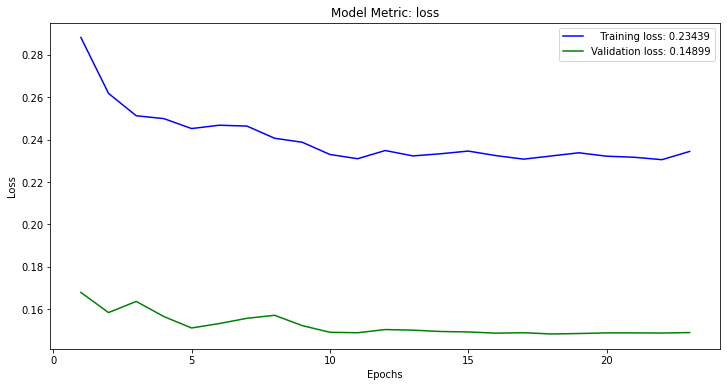

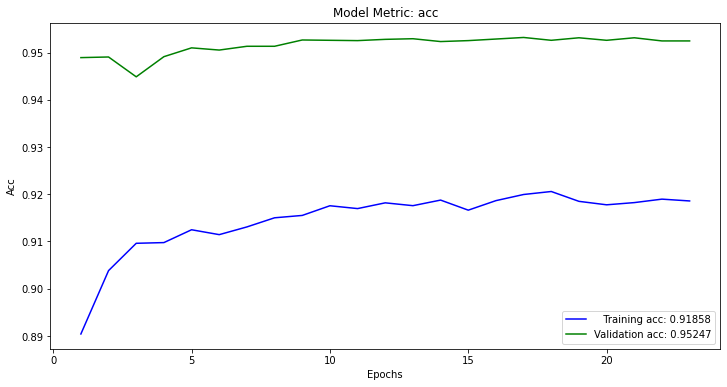

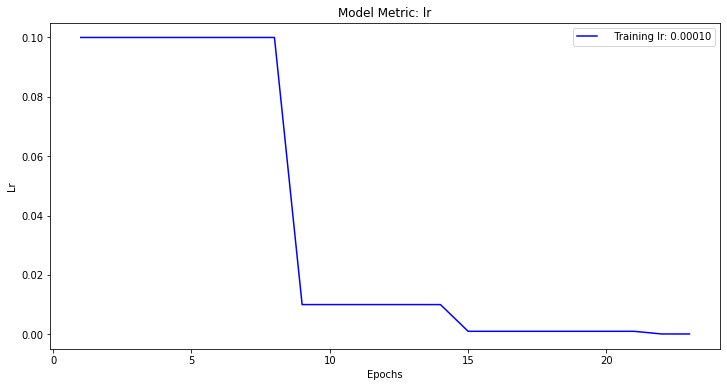

In [ ]:
plot_keras_history(history)

#### Extra info

In [ ]:
# Extra read
# https://en.wikipedia.org/wiki/Simulated_annealing
# You may create a CLR (cyclic learing rate) callback

# https://github.com/bckenstler/CLR